Stretch — only if you finished everything above
No marks. These exist so nobody sits idle.
• Compress a COLOUR image by running SVD on each of the three channels separately, then recombining.
Does colour need more or fewer singular values than grayscale?
• Build a tiny recommender: make a small user-by-item ratings matrix with gaps, run SVD, and use the low-rank
reconstruction to predict the missing ratings.
• Add noise to a clean matrix, then use a low-rank SVD approximation to remove it. SVD as a denoiser — why
does keeping only the top singular values discard noise?
• Time how long SVD takes on a 1000x1000 matrix versus eig on a 1000x1000 symmetric one. Which is more
expensive, and why?
• Plot singular values for three different images — a smooth gradient, a photo, and pure random noise. Which
compresses best, and how do their curves differ?


Image loaded successfully
Image shape: (537, 1024)


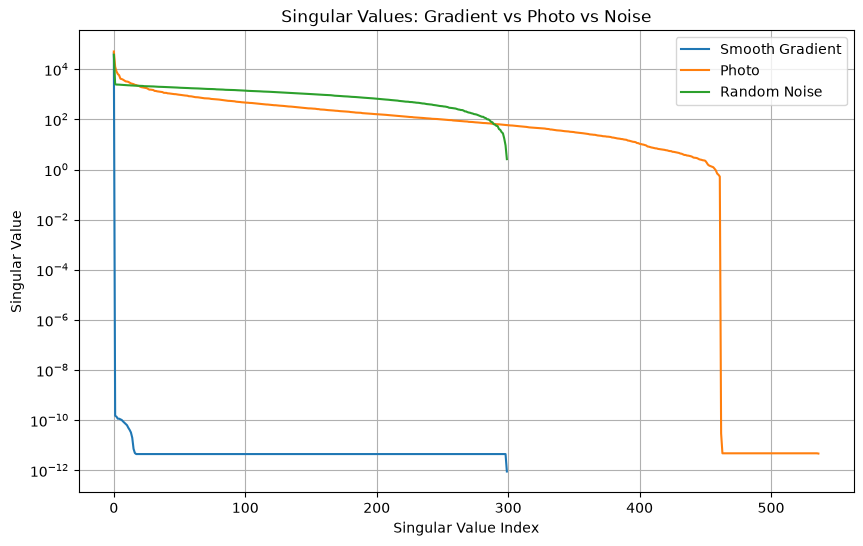

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open("CRMERP.webp").convert("L")
image = np.array(image, dtype=float)

print("Image loaded successfully")
print("Image shape:", image.shape)

# Q1 — Create smooth gradient
size = 300

gradient = np.tile(
    np.linspace(0, 255, size),
    (size, 1)
)

# Q2 — Create random noise
np.random.seed(42)

random_noise = np.random.rand(
    size,
    size
) * 255

# Q3 — Calculate singular values

# Smooth gradient
_, s_gradient, _ = np.linalg.svd(
    gradient,
    full_matrices=False
)

# Random noise
_, s_noise, _ = np.linalg.svd(
    random_noise,
    full_matrices=False
)

# Photo
# This requires that `image` was already loaded earlier.
_, s_photo, _ = np.linalg.svd(
    image,
    full_matrices=False
)

# Q4 — Plot them
plt.figure(figsize=(10, 6))

plt.semilogy(
    s_gradient,
    label="Smooth Gradient"
)

plt.semilogy(
    s_photo,
    label="Photo"
)

plt.semilogy(
    s_noise,
    label="Random Noise"
)

plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Values: Gradient vs Photo vs Noise")

plt.grid(True)
plt.legend()

plt.show()